In [92]:
import pandas as pd
import numpy as np

data_dir = "../data/raw"

customers = pd.read_csv(data_dir + "/customers.csv")
order_items = pd.read_csv(data_dir + "/order_items.csv")
orders = pd.read_csv(data_dir + "/orders.csv")
products = pd.read_csv(data_dir + "/products.csv")

print(customers.info())
print(order_items.info())
print(orders.info())
print(products.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  150 non-null    int64
 1   name         150 non-null    str  
 2   gender       150 non-null    str  
 3   age          150 non-null    int64
 4   city         150 non-null    str  
 5   signup_date  150 non-null    str  
dtypes: int64(2), str(4)
memory usage: 7.2 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 764 entries, 0 to 763
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   order_item_id  764 non-null    int64
 1   order_id       764 non-null    int64
 2   product_id     764 non-null    int64
 3   quantity       764 non-null    int64
 4   unit_price     764 non-null    int64
dtypes: int64(5)
memory usage: 30.0 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column 

In [93]:
from matplotlib import font_manager
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = ["Malgun Gothic", "AppleGothic", "Apple SD Gothic Neo", 
                  "Noto Sans CJK KR", "NanumGothic"]

In [94]:
import matplotlib.pyplot as plt

korean_font = next(
    (name for name in font_candidates if name in installed_fonts), None    
)

print("선택된 한글 폰트 : ",korean_font)

if korean_font:
    plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False

선택된 한글 폰트 :  Malgun Gothic


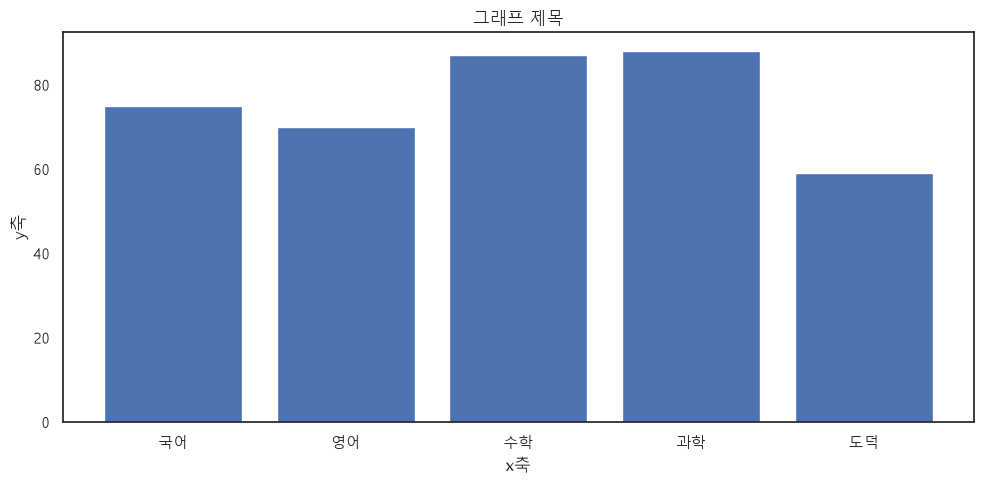

In [95]:
import matplotlib.pyplot as plt

x_data = ["국어", "영어", "수학", "과학", "도덕"]
y_data = [75, 70, 87, 88, 59]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_data, y_data)
ax.set_title("그래프 제목")
ax.set_xlabel("x축")
ax.set_ylabel("y축")
ax.set_ylim(bottom=0)
fig.tight_layout()

fig.savefig(
    "graph.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [96]:
orders.head()
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="raise")
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        300 non-null    int64         
 1   customer_id     300 non-null    int64         
 2   order_date      300 non-null    datetime64[us]
 3   payment_method  300 non-null    str           
 4   order_status    300 non-null    str           
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 11.8 KB


In [97]:
import os

print(os.getcwd())

c:\dev\llm-data-analysis-course\notebooks


In [98]:
from pathlib import Path

save_dir = Path("../data/processed")
save_dir.mkdir(parents=True, exist_ok=True)

products_cleaned.to_csv(
    save_dir / "products_cleaned.csv",
    encoding="utf-8-sig",
    index=False
)

In [99]:
df_visualization = pd.read_csv(
    "https://raw.githubusercontent.com/GilbertMoon/llm-data-analysis-course/refs/heads/main/data/processed/visualization.csv"
)

df_visualization.to_csv(
    "../data/processed/visualization.csv",
    encoding="utf-8-sig",
    index=False
)

In [100]:
df_visualization.info()

<class 'pandas.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    752 non-null    int64  
 1   order_id         752 non-null    int64  
 2   customer_id      750 non-null    float64
 3   product_id       752 non-null    int64  
 4   order_date       741 non-null    str    
 5   order_month      741 non-null    str    
 6   order_dayofweek  741 non-null    str    
 7   payment_method   750 non-null    str    
 8   order_status     750 non-null    str    
 9   gender           746 non-null    str    
 10  age              746 non-null    float64
 11  city             746 non-null    str    
 12  signup_date      734 non-null    str    
 13  product_name     726 non-null    str    
 14  category         726 non-null    str    
 15  price            726 non-null    float64
 16  quantity         752 non-null    float64
 17  unit_price       752 non-nu

In [101]:
df_visualization = df_visualization.dropna()

df_visualization.isna().sum().sum()

np.int64(0)

In [102]:
category_sales = df_visualization.groupby("category",  dropna=False, as_index=False).agg(
    total_amount=("line_total", sum),
    total_quantity=("quantity", sum),
).sort_values("total_amount",ascending=False)

category_sales

,category,total_amount,total_quantity
9,패션,63322000.0,532.0
6,식품,45972000.0,384.0
8,전자기기,34218000.0,280.0
0,도서,27876000.0,272.0
2,뷰티,26467000.0,268.0
5,스포츠,20468000.0,253.0
4,생활용품,13835000.0,204.0
3,생활 용품,3224000.0,26.0
1,뷰 티,1026000.0,19.0
7,전자 기기,252000.0,12.0


(0.0, 66488100.0)

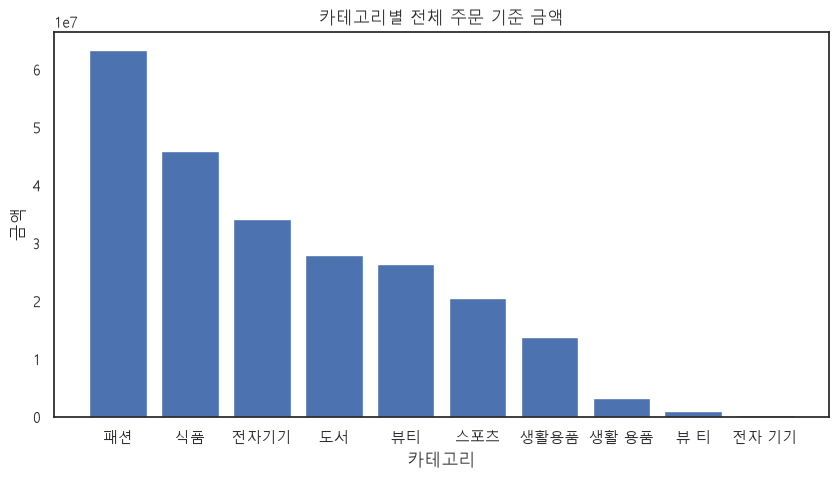

In [103]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    category_sales["category"],
    category_sales["total_amount"],
)

ax.set_title("카테고리별 전체 주문 기준 금액")
ax.set_xlabel("카테고리")
ax.set_ylabel("금액")

ax.set_ylim(bottom=0)

In [104]:
category_sales.info()

<class 'pandas.DataFrame'>
Index: 10 entries, 9 to 7
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   category        10 non-null     str    
 1   total_amount    10 non-null     float64
 2   total_quantity  10 non-null     float64
dtypes: float64(2), str(1)
memory usage: 320.0 bytes


In [105]:
df_visualization.info()

<class 'pandas.DataFrame'>
Index: 700 entries, 0 to 751
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    700 non-null    int64  
 1   order_id         700 non-null    int64  
 2   customer_id      700 non-null    float64
 3   product_id       700 non-null    int64  
 4   order_date       700 non-null    str    
 5   order_month      700 non-null    str    
 6   order_dayofweek  700 non-null    str    
 7   payment_method   700 non-null    str    
 8   order_status     700 non-null    str    
 9   gender           700 non-null    str    
 10  age              700 non-null    float64
 11  city             700 non-null    str    
 12  signup_date      700 non-null    str    
 13  product_name     700 non-null    str    
 14  category         700 non-null    str    
 15  price            700 non-null    float64
 16  quantity         700 non-null    float64
 17  unit_price       700 non-null   

In [106]:
monthly_sales = df_visualization.groupby("order_month", as_index=False).agg(
    total_amount = ("line_total", "sum"),
    order_count = ("order_id", "nunique")
)

Text(0, 0.5, '금액')

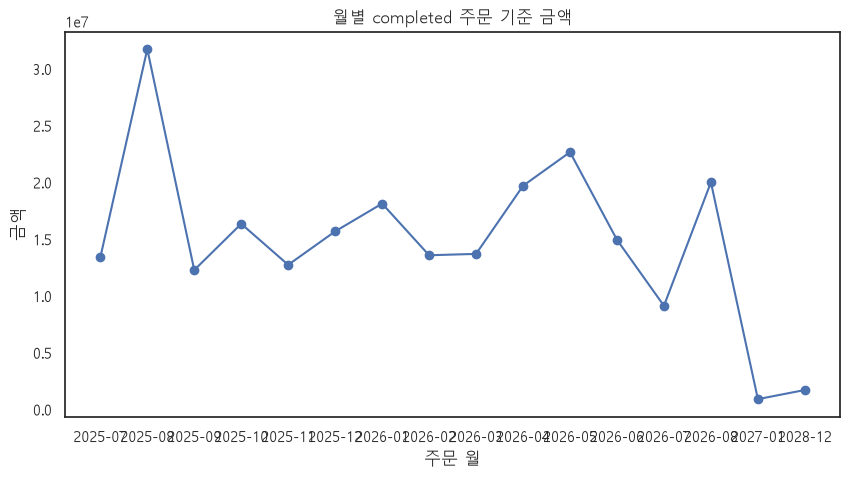

In [107]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    monthly_sales["order_month"],
    monthly_sales["total_amount"],
    marker="o",
)

ax.set_title("월별 completed 주문 기준 금액")
ax.set_xlabel("주문 월")
ax.set_ylabel("금액")

Text(0, 0.5, '상품 수')

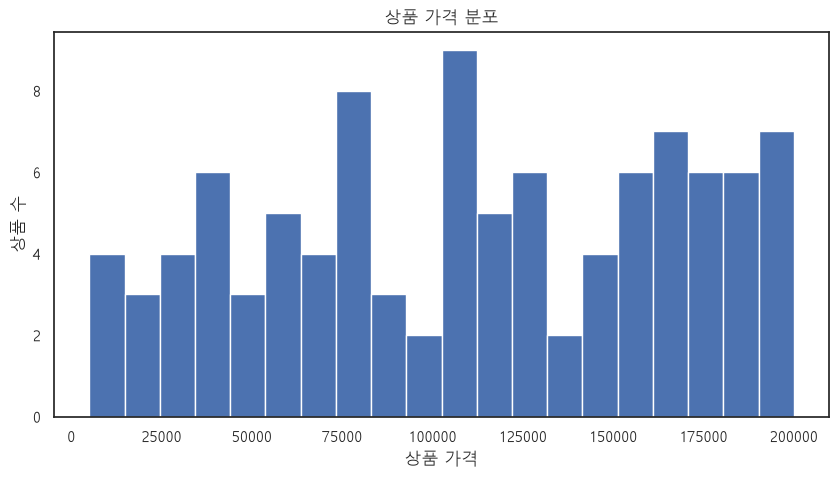

In [108]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    products["price"],
    bins=20,
)

ax.set_title("상품 가격 분포")

ax.set_xlabel("상품 가격")

ax.set_ylabel("상품 수")

Text(0, 0.5, '고객 수')

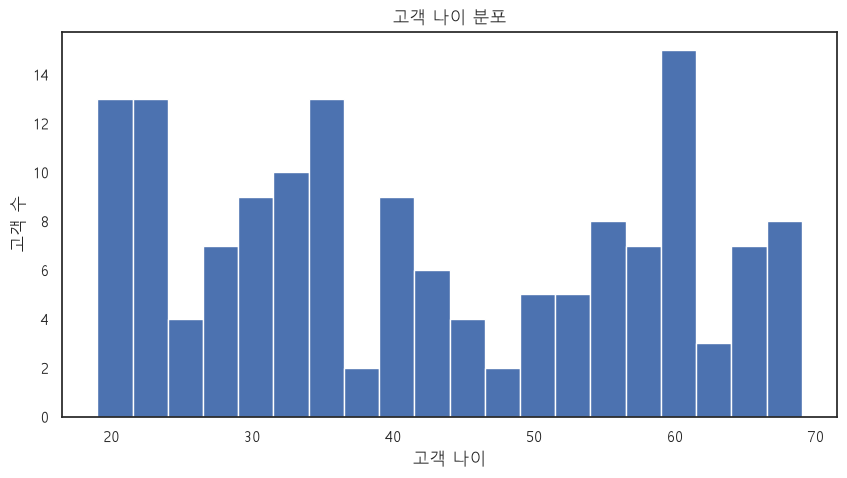

In [109]:
customersfig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    customers["age"],
    bins=20,
)

ax.set_title("고객 나이 분포")
ax.set_xlabel("고객 나이")
ax.set_ylabel("고객 수")

In [110]:
product_quantity = df_visualization.groupby("product_id", as_index=False).agg(
    total_quantity=("quantity", "sum")
)
product_quantity

,product_id,total_quantity
0,1,20.0
1,2,19.0
2,3,7.0
3,4,23.0
4,5,24.0
...,...,...
91,96,75.0
92,97,31.0
93,98,25.0
94,99,18.0


In [111]:
product_sales = df_visualization.groupby("product_id", as_index=False).agg(
    total_quantity = ("quantity", "sum"),
    total_amount = ("line_total", "sum"),
)

Text(0, 0.5, 'completed 판매 수량')

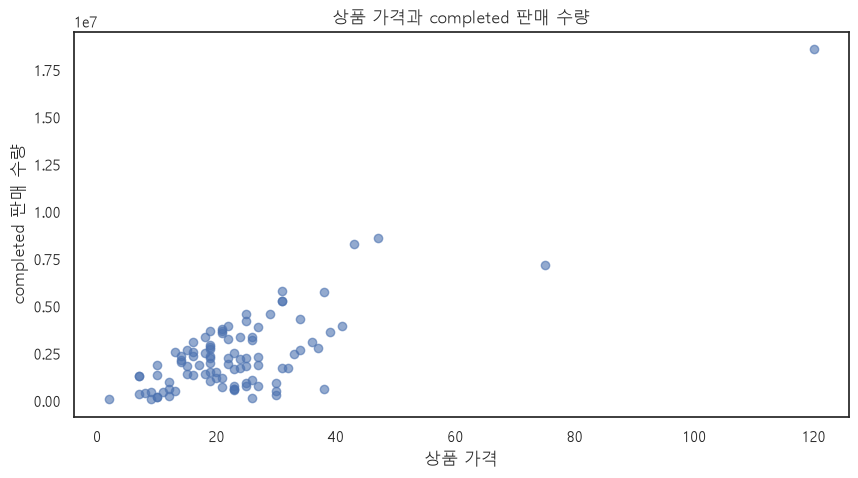

In [112]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    product_sales["total_quantity"],
    product_sales["total_amount"],
    alpha=0.6,
)
ax.set_title("상품 가격과 completed 판매 수량")
ax.set_xlabel("상품 가격")
ax.set_ylabel("completed 판매 수량")

In [113]:
customer_sales = df_visualization.groupby("customer_id",as_index=False).agg(
    total_amount = ("line_total", "sum"),
    order_count = ("order_id", "nunique"),
).sort_values("total_amount", ascending=False)

top_customers = customer_sales.head(10).reset_index(drop=True)

<BarContainer object of 10 artists>

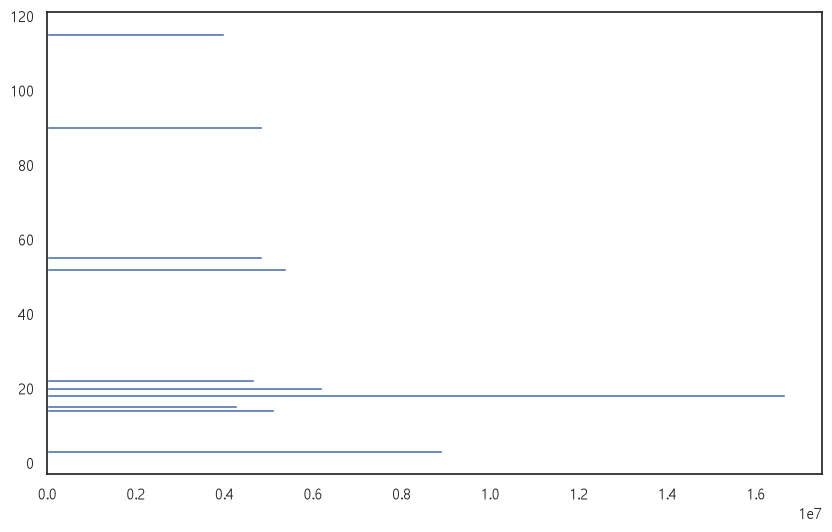

In [114]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_customers["customer_id"],
    top_customers["total_amount"],
)

In [115]:
customer_sales = df_visualization.groupby("customer_id",as_index=False).agg(
    total_amount = ("line_total", "sum"),
    order_count = ("order_id", "nunique"),
).sort_values("total_amount", ascending=False)

top_customers = customer_sales.head(10).reset_index(drop=True)

<BarContainer object of 10 artists>

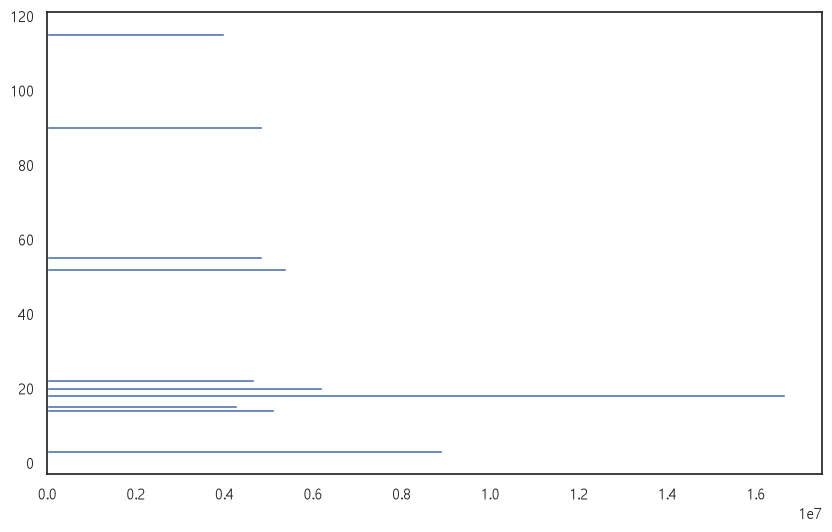

In [116]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_customers["customer_id"],
    top_customers["total_amount"],
)